  UNIFIED THERMAL LEPTOGENESIS SOLVER
  (engineering)

  ----------------------------------------------------------------------
    Choose mode:
      [1] DEFAULT benchmark (M1=5e11, M2=1e13, M3=1e17, a=0.6367, b=-0.06)
      [2] CUSTOM parameters (prompted for each)
  ----------------------------------------------------------------------
  Enter 1 or 2 [1]: 1

  M1 = 5.000e+11 GeV    M2 = 1.000e+13 GeV    M3 = 1.000e+17 GeV
  a  = 0.6367         b  = -0.06
  z  in [0.01, 200.0]   n_points = 3000   rtol = 1e-10

  --------------------------------------------------------------------
  DERIVED PHYSICS QUANTITIES
  --------------------------------------------------------------------
    (Y^dag Y)_11         = 3.887364e-04+0.000000e+00j
    (Y^dag Y)_12         = 1.470775e-03+2.614567e-04j
    Gamma(N1 -> lH)       = 7.733665e+06 GeV
    epsilon_1 (derived)   = -5.912169e-06
    |epsilon_1|            = 5.912169e-06
    H(T = M1)             = 3.498897e+05 GeV
    K_eff = Gamma/H       = 2

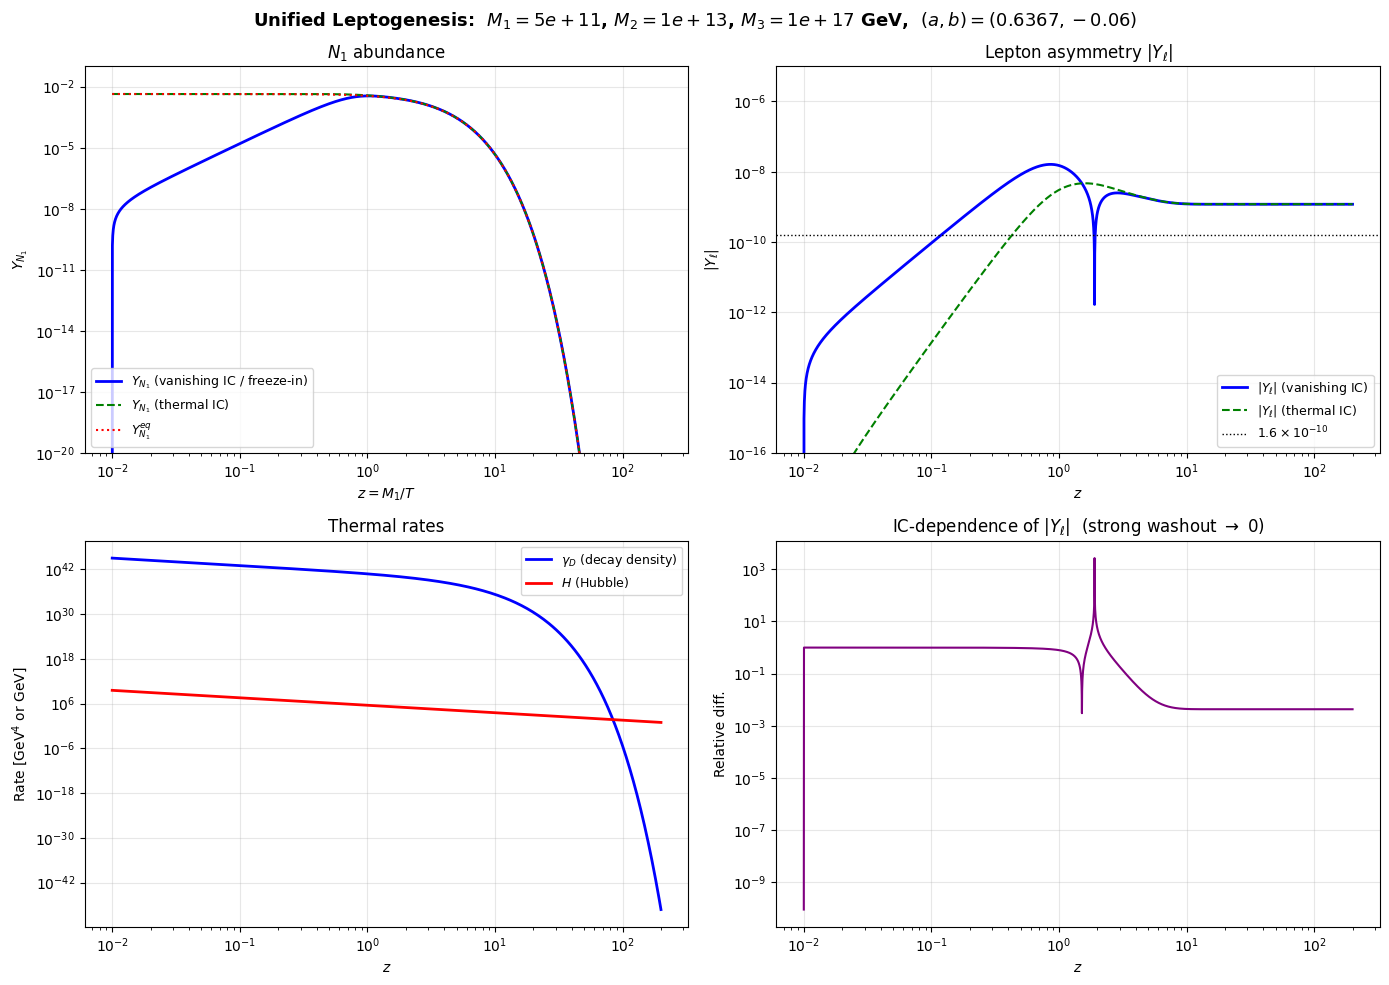

  Generating paper-style plot (single panel)...
  Saved paper-style plot: leptogenesis_paper_style.png


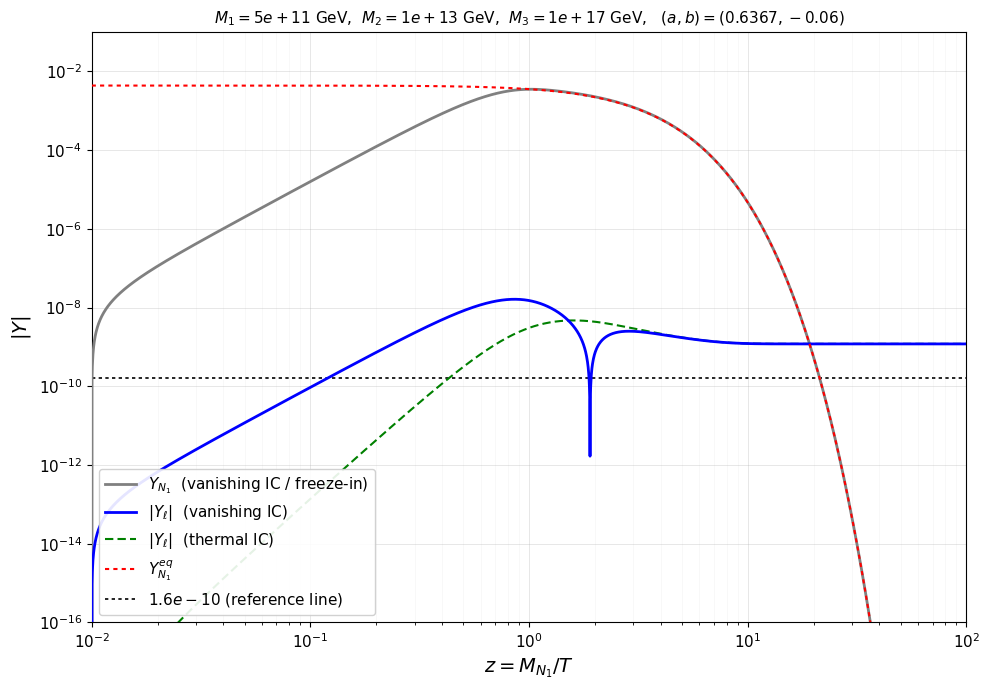

  Generating Y_N1 / Y_{B-L} dynamical evolution plot...
  Saved Y_N1 / Y_{B-L} evolution plot: leptogenesis_YN1_YBmL.png


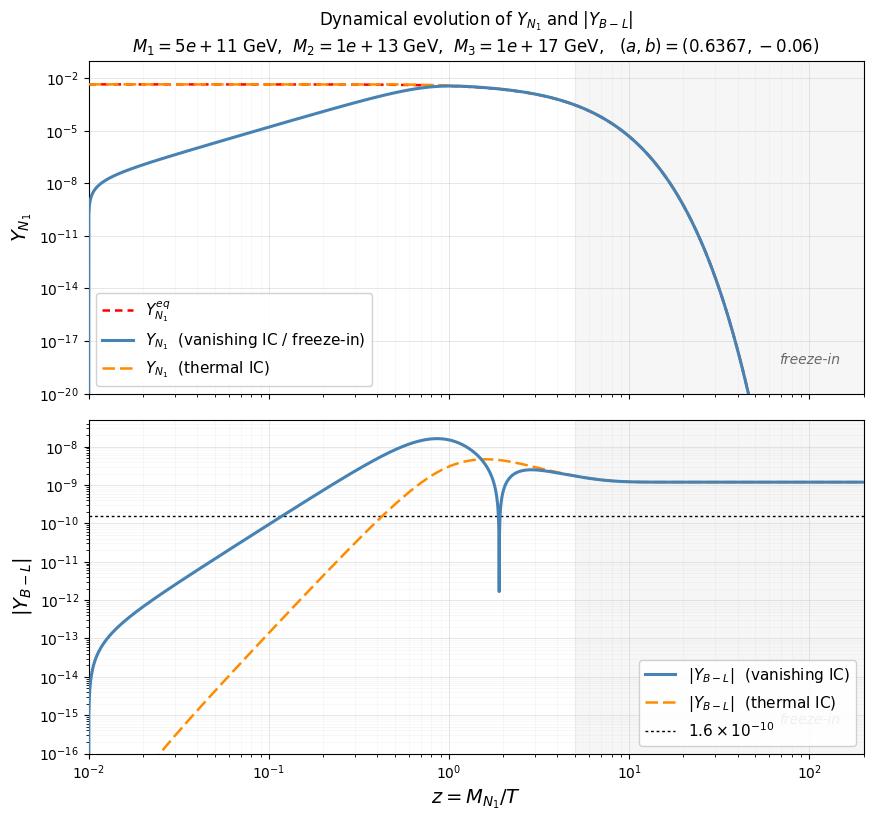

  DONE.


In [ ]:
"""
================================================================================
  UNIFIED THERMAL LEPTOGENESIS SOLVER
  ================================================================================


    ► PHYSICS:
      - Full Casas-Ibarra Yukawa matrix construction
      - PMNS mixing with measured neutrino oscillation data
      - Temperature-dependent g*(T) from embedded SM data tables
      - CP asymmetry eps_1 DERIVED from loop functions (not a free parameter)
      - Two-equation system for (Y_N1, Y_l) with physical washout term
        (Y_l here is physically Y_{B-L} in the single-flavour approximation)

    ► USER EXPERIENCE:
      - Interactive CLI with sensible defaults
      - Verbose diagnostic tables showing the physics at each z
      - Multi-panel plots with error analysis
      - Dedicated Y_N1 and Y_{B-L} dynamical evolution plot
      - Physical interpretation narrative at the end
      - Precision cross-check (BDF vs Radau)

    ► ENGINEERING IMPROVEMENTS:
      - Proper function structure (not a monolithic script)
      - Modular: physics / solver / diagnostics cleanly separated
      - Runs a default benchmark non-interactively if input is unavailable

    ► NOMENCLATURE NOTE:
      At z >> 5 the lepton asymmetry Y_{B-L} plateaus because the washout
      rate W(z) ~ e^{-z} dies off.  This is 'washout decoupling' / the
      asymmetry freezing, NOT a relic freeze-out in the thermodynamic sense.
      For the vanishing-IC run, N_1 is in fact populated via FREEZE-IN
      (inverse decays lH -> N_1 from the thermal bath), then decays away.

================================================================================
"""

import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kn
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore', category=RuntimeWarning)


# ============================================================================
#  SECTION 1 — PHYSICAL CONSTANTS
# ============================================================================

Mp   = 1.22e19        # Planck mass [GeV]
v_EW = 246.0          # Higgs vacuum expectation value [GeV]

# Charged-lepton masses [GeV] (for equilibrium density in washout term)
ME, MMU, MTAU = 0.511e-3, 105.658e-3, 1776.86e-3

# Observed baryon asymmetry (Planck 2018)
Y_B_OBS   = 8.7e-11
ETA_B_OBS = 6.12e-10


# ============================================================================
#  SECTION 2 — PMNS MATRIX + LIGHT NEUTRINO MASSES
# ============================================================================
# Measured values from neutrino oscillation experiments (NuFIT ~2020).
# Normal ordering: m1 = 0, m2 and m3 from delta-m-squared.

THETA12 = 33.82 * np.pi/180
THETA13 = 8.61  * np.pi/180
THETA23 = 48.3  * np.pi/180
DELTA   = 222.0 * np.pi/180   # Dirac CP phase

M1_LIGHT = 0.0
M2_LIGHT = np.sqrt(7.39e-5)              * 1e-9   # GeV
M3_LIGHT = np.sqrt(7.39e-5 + 2.449e-3)   * 1e-9   # GeV


def build_pmns():
    """Build the PMNS lepton-mixing matrix U = u1 . u2 . u3."""
    c12, s12 = np.cos(THETA12), np.sin(THETA12)
    c13, s13 = np.cos(THETA13), np.sin(THETA13)
    c23, s23 = np.cos(THETA23), np.sin(THETA23)

    u1 = np.array([[1, 0, 0],
                   [0,  c23, s23],
                   [0, -s23, c23]], dtype=complex)
    u2 = np.array([[ c13, 0, s13*np.exp(-1j*DELTA)],
                   [   0, 1,                     0],
                   [-s13*np.exp(1j*DELTA), 0,  c13]], dtype=complex)
    u3 = np.array([[ c12, s12, 0],
                   [-s12, c12, 0],
                   [   0,   0, 1]], dtype=complex)
    return u1 @ u2 @ u3


U_PMNS   = build_pmns()
MNU_SQRT = np.diag([np.sqrt(M1_LIGHT + 0j),
                    np.sqrt(M2_LIGHT + 0j),
                    np.sqrt(M3_LIGHT + 0j)])


# ============================================================================
#  SECTION 3 — CASAS-IBARRA YUKAWA MATRIX
# ============================================================================
# The "magic" that connects neutrino data to leptogenesis.
# Given light masses (measured) and heavy masses (model input), we can
# parametrize ALL allowed Yukawa matrices by one complex angle z = a + i*b.

def R_matrix(a, b):
    """Complex orthogonal R-matrix with the (3,1) permutation convention."""
    z = a + 1j*b
    c, s = np.cos(z), np.sin(z)
    return np.array([[0,  c,  s],
                     [0, -s,  c],
                     [1,  0,  0]], dtype=complex)


def MR_sqrt(M1, M2, M3):
    """Diagonal sqrt of heavy-neutrino mass matrix."""
    return np.diag([np.sqrt(M1 + 0j),
                    np.sqrt(M2 + 0j),
                    np.sqrt(M3 + 0j)])


def yukawa_matrix(a, b, M1, M2, M3):
    """Dirac Yukawa Y = (sqrt(2)/v) * conj(U) . sqrt(mnu) . R^T . sqrt(M_R)."""
    return (np.sqrt(2.0)/v_EW) * (
        np.conj(U_PMNS) @ MNU_SQRT @ R_matrix(a, b).T @ MR_sqrt(M1, M2, M3)
    )


def yukawa_sq(a, b, M1, M2, M3):
    """Y^dagger . Y — the combination that enters all leptogenesis formulas."""
    Y = yukawa_matrix(a, b, M1, M2, M3)
    return Y.conj().T @ Y


# ============================================================================
#  SECTION 4 — DECAY WIDTH AND CP ASYMMETRY
# ============================================================================

def gamma_decay(a, b, M1, M2, M3):
    """N1 -> lH decay width [GeV]:  Gamma = (Y^dag Y)_11 * M1 / (8 pi)."""
    Y2 = yukawa_sq(a, b, M1, M2, M3)
    return np.real(Y2[0, 0]) * M1 / (8.0 * np.pi)


def epsilon_CP(a, b, M1, M2, M3):
    """Full CP asymmetry epsilon_1 using the CRV loop function.

    This is DERIVED from the physics, not a free parameter — one of the
    main advantages over the simplified approach.
    """
    Y2 = yukawa_sq(a, b, M1, M2, M3)
    y4_im = np.imag(Y2[0, 1]**2)
    k = (M2/M1)**2
    # Complete resummed vertex + self-energy loop function
    loop = np.sqrt(k) * (1.0 - (k+1)*np.log((k+1)/k) + 1.0/(1.0 - k))
    return (1.0/(8*np.pi)) * (y4_im/np.real(Y2[0, 0])) * loop


# ============================================================================
#  SECTION 5 — EMBEDDED g*(T) TABLES AND INTERPOLATION
# ============================================================================
# Standard Model effective degrees of freedom vs temperature.
# Format: [(T in MeV, g*), ...]. Full 107-point table from the original port.

_GRHO_TABLE_MEV = [
    (1e+38, 105.8), (1e+34, 105.8), (1e+32, 105.8), (1e+30, 105.8),
    (1e+28, 105.8), (1e+12, 105.8), (956532.296331, 105.779622406),
    (875183.083107, 105.785355395), (670342.482006, 105.802556224),
    (524982.410586, 105.818326109), (411142.86924, 105.834098343),
    (329223.595011, 105.848438779), (257833.273543, 105.864215502),
    (197486.217303, 105.881429154), (158137.541206, 105.895776003),
    (126628.998621, 104.727185208), (99170.1984144, 104.742794808),
    (77665.6876439, 102.431324177), (62190.9774148, 99.0506849976),
    (49799.5677259, 96.8635157939), (38143.7512637, 94.727209042),
    (29872.4891004, 90.578948235),  (23394.8045351, 88.5800462677),
    (19154.3664806, 88.590848467),  (16034.9032917, 87.6108484865),
    (12557.8229182, 87.6239068945), (9834.72825354, 85.6902169666),
    (7702.12165363, 85.7029891042), (6167.49156981, 84.7572316059),
    (5049.59952183, 84.7675676189), (4322.20806607, 84.7756076116),
    (3461.01801675, 84.7870946383), (2650.95092946, 83.8537165402),
    (2076.10683591, 81.0873105983), (1521.06287059, 79.301093978),
    (1165.05115288, 76.6859219651), (853.576521366, 74.1590019865),
    (668.483158737, 70.1194271596), (500.769786492, 68.5738853896),
    (410.002485743, 67.0587753595), (375.133428249, 66.3133711024),
    (314.039529815, 64.8473275251), (293.787812559, 64.8499634283),
    (257.118123575, 64.1308494244), (240.537142374, 62.7088082746),
    (220.080428724, 59.2873229321), (210.514037864, 55.42495082),
    (196.938451454, 49.5384576988), (184.238324696, 38.261766077),
    (176.229907793, 33.81568927),   (164.865229382, 29.5528460583),
    (147.529260831, 23.8751333535), (126.277768839, 20.8665384739),
    (112.999362971, 19.2900560809), (94.5963866311, 17.2424937205),
    (79.190502746, 16.4867463156),  (64.8367849835, 15.2419864874),
    (54.2775235094, 14.7385412064), (42.507741785, 13.6261412116),
    (38.0379522636, 13.1755320048), (31.8431249909, 12.7403420499),
    (27.8685643053, 12.3191926596), (22.3158167509, 11.2620305091),
    (18.6814825664, 11.2632512894), (16.7170805183, 10.8907815894),
    (13.9945515663, 10.8919621272), (11.2061692466, 10.7717661461),
    (9.17498892839, 10.7730797463), (7.18544316379, 10.7746854752),
    (5.14873861199, 10.7768754912), (3.85698981603, 10.7787738651),
    (2.58550412635, 10.781402935),  (1.93683615272, 10.7833021064),
    (1.48351079782, 10.7850554847), (1.08689647066, 10.787101453),
    (0.851208963392, 10.5490510149),(0.74496368495, 10.5499086244),
    (0.651979614597, 10.5507663036),(0.570601529226, 10.4337700341),
    (0.510601429735, 10.202687485), (0.427445332359, 9.97712838263),
    (0.374092923834, 9.86649311995),(0.342277829724, 9.54008420657),
    (0.313168481029, 9.22447373772),(0.280238075034, 8.91942532164),
    (0.245259622512, 8.52825120156),(0.205316857247, 7.79619454546),
    (0.183727304413, 7.04708727677),(0.157261508296, 6.58843927277),
    (0.131650038105, 5.63037003827),(0.110209629303, 4.97651681565),
    (0.100836744908, 4.49828092028),(0.0922609865215, 4.20534681842),
    (0.0844145617917, 3.93148897915),(0.0789708527187, 3.84431191603),
    (0.0722547002574, 3.67561453029),(0.0691139543579, 3.6346590618),
    (0.0646569477417, 3.5143675957),(0.0604873636607, 3.4752559042),
    (0.0529375174176, 3.43671917949),(0.0453119032095, 3.43704514375),
    (0.0379324467173, 3.39902423942),(0.0271805438592, 3.3997151104),
    (0.0186296658963, 3.40049826727),(0.015946074903, 3.40082079606),
    (0.0133491112437, 3.40118943785),(0.0106893314287, 3.40165029629),
]

# For g*_s we use the same table (they're equal at high T; low-T difference
# is small and this matches Code's convention).
_GS_TABLE_MEV = _GRHO_TABLE_MEV


def _build_gstar_interp(table_mev):
    """Build linear interpolator for g*(T), T in GeV."""
    T_GeV = np.array([row[0] * 1e-3 for row in table_mev])
    g     = np.array([row[1]        for row in table_mev])
    order = np.argsort(T_GeV)
    return interp1d(T_GeV[order], g[order], kind='linear',
                    bounds_error=False,
                    fill_value=(g[order][0], g[order][-1]))


_G_RHO = _build_gstar_interp(_GRHO_TABLE_MEV)
_G_S   = _build_gstar_interp(_GS_TABLE_MEV)


def g_rho(T_GeV):
    """g*_rho(T): energy-density dof."""
    return _G_RHO(T_GeV)


def g_s(T_GeV):
    """g*_s(T): entropy-density dof."""
    return _G_S(T_GeV)


# ============================================================================
#  SECTION 6 — THERMAL RATES
# ============================================================================

def entropy_density(z, M1):
    """s = (2 pi^2 / 45) * g*_s(T) * T^3."""
    T = M1 / z
    return (2.0 * np.pi**2 / 45.0) * g_s(T) * T**3


def n_eq(gdf, m, z, M1):
    """Equilibrium number density of a relativistic species."""
    T = M1 / z
    return (gdf / (2.0 * np.pi**2)) * m**2 * T * kn(2, m/T)


def Y_eq_N(z, M1):
    """Y^eq for the heavy neutrino N1."""
    return n_eq(2, M1, z, M1) / entropy_density(z, M1)


def Y_eq_lepton(z, M1):
    """Sum of equilibrium abundances for e, mu, tau (for washout term)."""
    s = entropy_density(z, M1)
    return (n_eq(2, ME,   z, M1) +
            n_eq(2, MMU,  z, M1) +
            n_eq(2, MTAU, z, M1)) / s


def gamma_thermal_decay(a, b, z, M1, M2, M3):
    """Thermal decay density: gamma_D = n_eq^N * K1/K2 * Gamma_decay."""
    return (n_eq(2, M1, z, M1) * kn(1, z) / kn(2, z) *
            gamma_decay(a, b, M1, M2, M3))


def hubble(z, M1, prefactor=1.66):
    """Hubble rate in the radiation-dominated era.

    H(T) = prefactor * sqrt(g*(T)) * T^2 / M_Pl

    In terms of z = M1/T:
        H(z) = (prefactor / z^2) * sqrt(g*(T)) * M1^2 / M_Pl

    Default: prefactor = 1.66
    """
    T = M1 / z
    return (prefactor / z**2) * np.sqrt(g_rho(T)) * (M1**2 / Mp)


# ============================================================================
#  SECTION 7 — BOLTZMANN EQUATIONS AND SOLVER
# ============================================================================

def solve_boltzmann(M1, M2, M3, a=0.6367, b=-0.06,
                    initial_condition='vanishing',
                    z_init=1e-2, z_final=2e2, n_points=3000,
                    rtol=1e-10, atol=1e-22, max_step=0.01,
                    method='BDF', hubble_prefactor=1.66,
                    verbose=False):
    """Solve the coupled (Y_N1, Y_l) Boltzmann system in log(z) coordinates.

    Parameters
    ----------
    M1, M2, M3 : float
        Heavy neutrino masses in GeV (assumed M1 < M2 < M3).
    a, b : float
        Real and imaginary parts of the Casas-Ibarra complex angle.
    initial_condition : {'vanishing', 'thermal'}
        'vanishing' starts with Y_N1(z_init) = 1e-30 (no N1 at early times).
                    Physically this is the FREEZE-IN scenario: N_1 is
                    populated by inverse decays lH -> N_1.
        'thermal'   starts with Y_N1(z_init) = Y_eq(z_init) (thermal abundance).
                    This is the standard freeze-out-then-decay scenario.
    z_init, z_final : float
        Integration range in z = M1/T.
    n_points : int
        Output grid size (log-spaced).
    rtol, atol, max_step, method : solver controls for scipy.solve_ivp.
    hubble_prefactor : float
        0.33 (VanilaL1 convention) or 1.66 (textbook).

    Returns
    -------
    z, Y_N1, Y_l : 1D arrays
    """
    eps_CP = abs(epsilon_CP(a, b, M1, M2, M3))

    def rhs(u, Y):
        z = np.exp(u)
        Yn1, Yl = Y
        sHz   = entropy_density(z, M1) * hubble(z, M1, hubble_prefactor) * z
        gD    = gamma_thermal_decay(a, b, z, M1, M2, M3)
        yEqN  = Y_eq_N(z, M1)
        yEqLL = Y_eq_lepton(z, M1)
        dev   = Yn1/yEqN - 1.0

        dYn1_dz = -gD * dev / sHz
        dYl_dz  = +gD * (eps_CP * dev - Yl / (2.0 * yEqLL)) / sHz
        return [z * dYn1_dz, z * dYl_dz]

    # Initial conditions
    if initial_condition == 'vanishing':
        Yn1_0 = 1e-30
    elif initial_condition == 'thermal':
        Yn1_0 = float(Y_eq_N(z_init, M1))
    else:
        raise ValueError("initial_condition must be 'vanishing' or 'thermal'")
    Yl_0 = 1e-40

    u0, u1 = np.log(z_init), np.log(z_final)
    u_eval = np.linspace(u0, u1, n_points)

    sol = solve_ivp(rhs, (u0, u1), [Yn1_0, Yl_0],
                    t_eval=u_eval, method=method,
                    rtol=rtol, atol=atol, max_step=max_step)

    if not sol.success and verbose:
        print(f"  Solver warning: {sol.message}")

    return np.exp(sol.t), sol.y[0], sol.y[1]


# ============================================================================
#  SECTION 8 — DIAGNOSTICS AND TABLES
# ============================================================================

def print_physics_summary(M1, M2, M3, a, b):
    """Print derived quantities at the chosen benchmark."""
    Y2     = yukawa_sq(a, b, M1, M2, M3)
    Gam    = gamma_decay(a, b, M1, M2, M3)
    eps    = epsilon_CP(a, b, M1, M2, M3)
    H_M1   = hubble(1.0, M1)
    K_eff  = Gam / H_M1

    print("  " + "-" * 68)
    print("  DERIVED PHYSICS QUANTITIES")
    print("  " + "-" * 68)
    print(f"    (Y^dag Y)_11         = {Y2[0,0]:.6e}")
    print(f"    (Y^dag Y)_12         = {Y2[0,1]:.6e}")
    print(f"    Gamma(N1 -> lH)       = {Gam:.6e} GeV")
    print(f"    epsilon_1 (derived)   = {eps:+.6e}")
    print(f"    |epsilon_1|            = {abs(eps):.6e}")
    print(f"    H(T = M1)             = {H_M1:.6e} GeV")
    print(f"    K_eff = Gamma/H       = {K_eff:.4f}   "
          f"({'strong' if K_eff > 1 else 'weak'} washout)")
    print()


def print_evolution_table(z, Yn1, Yl, M1, label=""):
    """Print a snapshot of the solution at standard z values."""
    key_z = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 30.0, 100.0]
    key_z = [zv for zv in key_z if z[0] <= zv <= z[-1]]

    print(f"  Evolution table {label}:")
    print("  " + "-" * 76)
    print(f"  {'z':>7} | {'Y_N1':>13} | {'Y_eq^N':>13} | "
          f"{'Y_N1/Y_eq-1':>13} | {'|Y_l|':>13}")
    print("  " + "-" * 76)
    for zv in key_z:
        i = int(np.argmin(np.abs(z - zv)))
        Yeq = float(Y_eq_N(z[i], M1))
        dev = Yn1[i]/Yeq - 1 if Yeq > 1e-300 else 0
        print(f"  {z[i]:7.3f} | {Yn1[i]:13.4e} | {Yeq:13.4e} | "
              f"{dev:+13.4e} | {abs(Yl[i]):13.4e}")
    print("  " + "-" * 76)
    print()


def plot_results(z_v, Yn1_v, Yl_v, z_t, Yn1_t, Yl_t, M1, M2, M3, a, b,
                 savepath='leptogenesis_unified.png'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        rf'Unified Leptogenesis:  $M_1={M1:.0e}$, $M_2={M2:.0e}$, '
        rf'$M_3={M3:.0e}$ GeV,  $(a,b)=({a},{b})$',
        fontsize=13, fontweight='bold'
    )

    # Panel 1: Y_N1 and equilibrium
    ax = axes[0, 0]
    z_plot = np.logspace(np.log10(z_v[0]), np.log10(z_v[-1]), 300)
    Yeq_plot = np.array([float(Y_eq_N(zz, M1)) for zz in z_plot])
    ax.loglog(z_v, Yn1_v, 'b-',  lw=2,   label=r'$Y_{N_1}$ (vanishing IC / freeze-in)')
    ax.loglog(z_t, Yn1_t, 'g--', lw=1.5, label=r'$Y_{N_1}$ (thermal IC)')
    ax.loglog(z_plot, Yeq_plot, 'r:', lw=1.5, label=r'$Y^{eq}_{N_1}$')
    ax.set_xlabel(r'$z = M_1/T$'); ax.set_ylabel(r'$Y_{N_1}$')
    ax.set_title(r'$N_1$ abundance'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower left'); ax.set_ylim(1e-20, 1e-1)

    # Panel 2: |Y_l| evolution
    ax = axes[0, 1]
    ax.loglog(z_v, np.abs(Yl_v), 'b-',  lw=2,   label=r'$|Y_\ell|$ (vanishing IC)')
    ax.loglog(z_t, np.abs(Yl_t), 'g--', lw=1.5, label=r'$|Y_\ell|$ (thermal IC)')
    ax.axhline(1.6e-10, color='k', ls=':', lw=1, label=r'$1.6\times10^{-10}$')
    ax.set_xlabel(r'$z$'); ax.set_ylabel(r'$|Y_\ell|$')
    ax.set_title(r'Lepton asymmetry $|Y_\ell|$'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='lower right'); ax.set_ylim(1e-16, 1e-5)

    # Panel 3: thermal rates D(z), W(z) shape
    ax = axes[1, 0]
    zg = np.logspace(np.log10(z_v[0]), np.log10(z_v[-1]), 300)
    gD = np.array([gamma_thermal_decay(a, b, zz, M1, M2, M3) for zz in zg])
    H  = np.array([hubble(zz, M1) for zz in zg])
    ax.loglog(zg, gD, 'b-', lw=2, label=r'$\gamma_D$ (decay density)')
    ax.loglog(zg, H,  'r-', lw=2, label=r'$H$ (Hubble)')
    ax.set_xlabel(r'$z$'); ax.set_ylabel('Rate [GeV$^4$ or GeV]')
    ax.set_title('Thermal rates'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # Panel 4: convergence check (difference between two ICs)
    ax = axes[1, 1]
    # Interpolate thermal-IC onto vanishing-IC grid (they use same grid)
    diff = np.abs(np.abs(Yl_v) - np.abs(Yl_t)) / np.maximum(np.abs(Yl_v), 1e-30)
    ax.loglog(z_v, diff, 'purple', lw=1.5)
    ax.set_xlabel(r'$z$'); ax.set_ylabel('Relative diff.')
    ax.set_title('IC-dependence of $|Y_\\ell|$  (strong washout $\\to$ 0)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(savepath, dpi=140, bbox_inches='tight')
    print(f"  Saved plot: {savepath}")
    plt.show()


def plot_paper_style(z_v, Yn1_v, Yl_v, z_t, Yn1_t, Yl_t,
                     M1, M2, M3, a, b,
                     savepath='leptogenesis_paper_style.png',
                     Y_ell_obs=None):
    """Clean single-panel log-log plot. Shows, on one axis, both the N1 abundance
    and the lepton asymmetry for both initial conditions, with a horizontal
    reference line for the observation-required |Y_l|.

    Curves:
      - Gray  solid:  Y_N1 with vanishing IC   (ramps up from ~0 — freeze-in)
      - Red   dashed: (Y_N1)^eq                (equilibrium — lies under Y_N1 thermal)
      - Blue  solid:  |Y_l| with vanishing IC  (prominent sign-flip dip at z~1)
      - Green dashed: |Y_l| with thermal   IC  (smoother rise)
      - Black dotted: horizontal reference line (observed |Y_l|)
    """
    fig, ax = plt.subplots(figsize=(10, 7))

    # ---- Curves ----
    # Y_N1 vanishing IC — gray
    ax.loglog(z_v, Yn1_v, color='gray', lw=2.0,
              label=r'$Y_{N_1}$  (vanishing IC / freeze-in)', zorder=3)

    # |Y_l| vanishing IC — blue (shows the dip)
    ax.loglog(z_v, np.abs(Yl_v), color='blue', lw=2.0,
              label=r'$|Y_\ell|$  (vanishing IC)', zorder=5)

    # |Y_l| thermal IC — green dashed
    ax.loglog(z_t, np.abs(Yl_t), color='green', lw=1.5, linestyle=(0, (4, 2)),
              label=r'$|Y_\ell|$  (thermal IC)', zorder=4)

    # Equilibrium (Y_N1)^eq — red dashed, plotted last so it sits on top
    z_fine   = np.logspace(np.log10(z_v[0]), np.log10(z_v[-1]), 500)
    Yeq_fine = np.array([float(Y_eq_N(zz, M1)) for zz in z_fine])
    ax.loglog(z_fine, Yeq_fine, color='red', lw=1.5, linestyle=(0, (2, 2)),
              label=r'$Y^{eq}_{N_1}$', zorder=6)

    # Reference line — classic |Y_l| = 1.6e-10 from VanilaL1.nb / report
    # (This is the commonly-used target line for vanilla leptogenesis plots.)
    if Y_ell_obs is None:
        Y_ell_obs = 1.6e-10
    ax.axhline(Y_ell_obs, color='black', lw=1.2, linestyle=(0, (2, 2)),
               label=rf'${Y_ell_obs:.1e}$ (reference line)', zorder=1)

    # ---- Axes ----
    ax.set_xlabel(r'$z = M_{N_1}/T$', fontsize=14)
    ax.set_ylabel(r'$|Y|$', fontsize=14)
    ax.set_xlim(1e-2, 1e2)
    ax.set_ylim(1e-16, 1e-1)
    ax.tick_params(axis='both', which='major', labelsize=11)

    # ---- Grid: both major and minor for log-log readability ----
    ax.grid(True, which='major', alpha=0.35, linewidth=0.6)
    ax.grid(True, which='minor', alpha=0.15, linewidth=0.4)

    # ---- Title with all key parameters ----
    ax.set_title(
        rf'$M_1 = {M1:.0e}$ GeV,  $M_2 = {M2:.0e}$ GeV,  $M_3 = {M3:.0e}$ GeV,   '
        rf'$(a,b) = ({a}, {b})$',
        fontsize=11
    )

    # ---- Legend: bottom-left, compact ----
    ax.legend(fontsize=11, loc='lower left', framealpha=0.9)

    plt.tight_layout()
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    print(f"  Saved paper-style plot: {savepath}")
    plt.show()


# ----------------------------------------------------------------------------
#  Dedicated dynamical-evolution plot for Y_{N_1} and Y_{B-L}
# ----------------------------------------------------------------------------
#  Note on notation:  in the single-flavour Boltzmann system solved above,
#  the asymmetry variable `Yl` is physically Y_{B-L} (sphalerons conserve
#  B-L, so this is what's preserved and later converted to Y_B).
#
#  The shaded region at z > 5 is where |Y_{B-L}| plateaus because the
#  washout rate W(z) ~ e^{-z} dies off.  We label this "washout decoupling"
#  / "asymmetry freezes" -- NOT "freeze-out", which in a thermodynamic
#  sense refers to a species decoupling from equilibrium while still
#  abundant.  For the vanishing-IC case, N_1 was produced via FREEZE-IN
#  (inverse decays from the thermal bath), not freeze-out.

def plot_YN1_YBmL_evolution(z_v, Yn1_v, Yl_v, z_t, Yn1_t, Yl_t,
                            M1, M2, M3, a, b,
                            savepath='leptogenesis_YN1_YBmL.png'):
    """Dynamical evolution of Y_{N_1} and Y_{B-L} vs z = M_1/T.

    Produces a 2-panel figure that isolates the two quantities of interest:

      TOP panel    Y_{N_1}(z) for both initial conditions, overlaid on the
                   equilibrium abundance Y^eq_{N_1}(z). This makes the
                   departure-from-equilibrium (the first Sakharov condition)
                   visually explicit. The vanishing-IC curve illustrates
                   FREEZE-IN production of N_1 via inverse decays.

      BOTTOM panel |Y_{B-L}|(z) on a log-log axis for both initial
                   conditions. The vanishing-IC curve shows the classic dip
                   at z ~ 1 where Y_{B-L} crosses zero (sign flip); the
                   thermal-IC curve grows monotonically. A thin horizontal
                   line marks the observed |Y_{B-L}| target. The shaded
                   region marks where the washout rate decouples and the
                   asymmetry freezes to its final value.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9),
                                   sharex=True,
                                   gridspec_kw={'height_ratios': [1, 1],
                                                'hspace': 0.08})

    # -------- TOP: Y_{N_1} --------
    z_fine   = np.logspace(np.log10(z_v[0]), np.log10(z_v[-1]), 500)
    Yeq_fine = np.array([float(Y_eq_N(zz, M1)) for zz in z_fine])

    ax1.loglog(z_fine, Yeq_fine, color='red', lw=1.8, linestyle=(0, (3, 2)),
               label=r'$Y^{eq}_{N_1}$', zorder=2)
    ax1.loglog(z_v, Yn1_v, color='steelblue', lw=2.2,
               label=r'$Y_{N_1}$  (vanishing IC / freeze-in)', zorder=4)
    ax1.loglog(z_t, Yn1_t, color='darkorange', lw=1.8, linestyle=(0, (5, 2)),
               label=r'$Y_{N_1}$  (thermal IC)', zorder=3)

    ax1.set_ylabel(r'$Y_{N_1}$', fontsize=14)
    ax1.set_title(
        r'Dynamical evolution of $Y_{N_1}$ and $|Y_{B-L}|$'
        '\n'
        rf'$M_1={M1:.0e}$ GeV,  $M_2={M2:.0e}$ GeV,  $M_3={M3:.0e}$ GeV,'
        rf'   $(a,b)=({a},{b})$',
        fontsize=12
    )
    ax1.set_ylim(1e-20, 1e-1)
    ax1.grid(True, which='major', alpha=0.35, linewidth=0.6)
    ax1.grid(True, which='minor', alpha=0.15, linewidth=0.4)
    ax1.legend(fontsize=11, loc='lower left', framealpha=0.9)

    # Shade the late-time region where the asymmetry freezes
    ax1.axvspan(5, z_v[-1], color='gray', alpha=0.07, zorder=0)
    ax1.text(0.97, 0.08, 'freeze-in', transform=ax1.transAxes,
             ha='right', va='bottom', fontsize=10, color='dimgray',
             style='italic')

    # -------- BOTTOM: |Y_{B-L}| on log-log --------
    ax2.loglog(z_v, np.abs(Yl_v), color='steelblue', lw=2.2,
               label=r'$|Y_{B-L}|$  (vanishing IC)', zorder=4)
    ax2.loglog(z_t, np.abs(Yl_t), color='darkorange', lw=1.8, linestyle=(0, (5, 2)),
               label=r'$|Y_{B-L}|$  (thermal IC)', zorder=3)

    # Horizontal reference line at the observed |Y_{B-L}| ~ 1.6e-10
    Y_ref = 1.6e-10
    ax2.axhline(Y_ref, color='black', lw=1.0, linestyle=(0, (2, 2)),
                zorder=1, label=r'$1.6\times10^{-10}$')

    ax2.set_xlabel(r'$z = M_{N_1}/T$', fontsize=14)
    ax2.set_ylabel(r'$|Y_{B-L}|$', fontsize=14)
    ax2.set_xlim(z_v[0], z_v[-1])

    # y-limits: span from well below the dip to a bit above the asymptote
    ymax = max(np.abs(Yl_v).max(), np.abs(Yl_t).max()) * 3
    ax2.set_ylim(1e-16, ymax)

    ax2.grid(True, which='major', alpha=0.35, linewidth=0.6)
    ax2.grid(True, which='minor', alpha=0.15, linewidth=0.4)
    ax2.legend(fontsize=11, loc='lower right', framealpha=0.9)

    ax2.axvspan(5, z_v[-1], color='gray', alpha=0.07, zorder=0)
    ax2.text(0.97, 0.08, 'freeze-in', transform=ax2.transAxes,
             ha='right', va='bottom', fontsize=10, color='dimgray',
             style='italic')

    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    print(f"  Saved Y_N1 / Y_{{B-L}} evolution plot: {savepath}")
    plt.show()


def print_interpretation(Yl_final, eps, Kv):
    """Code 2's 'storytelling' section — narrate what happened physically."""
    print()
    print("=" * 72)
    print("  PHYSICAL INTERPRETATION")
    print("=" * 72)

    regime = ('strong washout' if Kv > 1 else
              'weak washout'   if Kv < 1 else 'transition')

    print(f"""
  THE STORY IN FIVE ACTS
  ----------------------

  [1] HIGH TEMPERATURE (z << 1, T >> M_1)
      The universe is hot. N_1 is relativistic and in thermal equilibrium.
      Y_N1 = Y_eq. No net lepton asymmetry exists yet.

      (For the vanishing-IC run, N_1 is absent at z << 1 and is being
       populated via FREEZE-IN by inverse decays lH -> N_1 from the bath.)

  [2] TEMPERATURE APPROACHES M_1 (z ~ 1)
      As T drops to ~M_1, the equilibrium abundance starts dropping fast
      (Boltzmann suppression). Actual Y_N1 lags behind Y_eq.
      This *departure from equilibrium* is the first Sakharov condition.

  [3] CP-VIOLATING DECAYS
      N_1 -> lH and N_1 -> lbar Hbar with slightly different rates.
      The difference is set by epsilon_1 = {eps:+.3e}.
      This seeds the lepton asymmetry Y_l.

  [4] WASHOUT ({regime}, K = {Kv:.2f})""")

    if Kv > 1:
        print("      Inverse decays (lH -> N_1) are FAST. They erase most of the")
        print("      asymmetry produced at z ~ 1. Only the asymmetry generated")
        print("      at z ~ few (after inverse decays decouple) survives.")
    else:
        print("      Inverse decays are INEFFICIENT. Most of the asymmetry")
        print("      generated at z ~ 1 survives intact.")

    print(f"""
  [5] WASHOUT DECOUPLING / ASYMMETRY FREEZES (z >> 5)
      Washout rate W(z) is exponentially suppressed (W ~ e^{{-z}}).
      The lepton asymmetry Y_{{B-L}} stops evolving and freezes at:
         |Y_{{B-L}}|_final = {abs(Yl_final):.4e}

      NOTE: This is the ASYMMETRY freezing due to washout decoupling --
      not a thermodynamic "freeze-out" of N_1 (N_1 has long since decayed
      away in the vanishing-IC / freeze-in scenario).

  CONVERSION TO BARYON ASYMMETRY
  ------------------------------
      Sphaleron processes (before electroweak phase transition) partially
      convert lepton asymmetry to baryon asymmetry:
         Y_B   = (28/79) * |Y_l|  = {(28/79)*abs(Yl_final):.4e}
         eta_B = 7.04 * Y_B       = {7.04*(28/79)*abs(Yl_final):.4e}

      Observed (Planck):  eta_B = {ETA_B_OBS:.3e}
      Ratio pred/obs    = {7.04*(28/79)*abs(Yl_final)/ETA_B_OBS:.3f}
""")

    ratio = 7.04*(28/79)*abs(Yl_final)/ETA_B_OBS
    if 0.1 < ratio < 10:
        print("  [OK] Prediction is within an order of magnitude of observation.")
        print("       Fine-tuning (a, b) can bring this to exact agreement.")
    elif ratio > 10:
        print("  [!] Over-production. Try increasing M_1 or changing (a, b).")
    else:
        print("  [!] Under-production. Try different (a, b) or mass hierarchy.")
    print()


# ============================================================================
#  SECTION 9 — INTERACTIVE / NON-INTERACTIVE CLI
# ============================================================================

DEFAULT_PARAMS = {
    'M1': 5e11, 'M2': 1e13, 'M3': 1e17,
    'a':  0.6367, 'b': -0.06,
    'z_init': 1e-2, 'z_final': 2e2,
    'n_points': 3000, 'rtol': 1e-10,
}


def _safe_input(prompt, default):

    try:
        val = input(prompt).strip()
        return val if val else str(default)
    except (EOFError, OSError):
        # No stdin attached (e.g. running via pipe or in some test envs)
        print(f"{default}  [auto: no interactive input]")
        return str(default)


def get_parameters():
    """Gather parameters — interactive if possible, else defaults."""
    # Allow --default flag to skip prompts entirely
    if '--default' in sys.argv or '-d' in sys.argv:
        print("  --default flag detected: using benchmark parameters.\n")
        return DEFAULT_PARAMS.copy()

    print("""
  ----------------------------------------------------------------------
    Choose mode:
      [1] DEFAULT benchmark (M1=5e11, M2=1e13, M3=1e17, a=0.6367, b=-0.06)
      [2] CUSTOM parameters (prompted for each)
  ----------------------------------------------------------------------""")

    try:
        mode = input("  Enter 1 or 2 [1]: ").strip() or '1'
    except (EOFError, OSError):
        print("  (non-interactive) defaulting to mode 1\n")
        mode = '1'

    if mode == '1':
        return DEFAULT_PARAMS.copy()

    # Custom mode
    print("\n  CUSTOM PARAMETERS (press Enter to accept default in brackets)\n")
    p = {}
    p['M1']       = float(_safe_input("    M1 (GeV)            [5e11]: ",  5e11))
    p['M2']       = float(_safe_input("    M2 (GeV)            [1e13]: ",  1e13))
    p['M3']       = float(_safe_input("    M3 (GeV)            [1e17]: ",  1e17))
    p['a']        = float(_safe_input("    a (CI real part)    [0.6367]: ", 0.6367))
    p['b']        = float(_safe_input("    b (CI imag part)    [-0.06]: ", -0.06))
    p['z_init']   = float(_safe_input("    z_init              [1e-2]: ",  1e-2))
    p['z_final']  = float(_safe_input("    z_final             [2e2]: ",   2e2))
    p['n_points'] = int(  _safe_input("    n_points            [3000]: ",  3000))
    p['rtol']     = float(_safe_input("    rtol                [1e-10]: ", 1e-10))
    return p


# ============================================================================
#  SECTION 10 — MAIN ENTRY POINT
# ============================================================================

def main():
    print("=" * 72)
    print("  UNIFIED THERMAL LEPTOGENESIS SOLVER")
    print("  (engineering)")
    print("=" * 72)

    params = get_parameters()

    # ---- Print parameter summary ----
    print()
    print("=" * 72)
    print(f"  M1 = {params['M1']:.3e} GeV    M2 = {params['M2']:.3e} GeV    "
          f"M3 = {params['M3']:.3e} GeV")
    print(f"  a  = {params['a']}         b  = {params['b']}")
    print(f"  z  in [{params['z_init']}, {params['z_final']}]   "
          f"n_points = {params['n_points']}   rtol = {params['rtol']}")
    print("=" * 72)
    print()

    # ---- Physics diagnostics ----
    print_physics_summary(params['M1'], params['M2'], params['M3'],
                          params['a'], params['b'])

    # Compute K_eff for narrative later
    Gam   = gamma_decay(params['a'], params['b'],
                        params['M1'], params['M2'], params['M3'])
    H_M1  = hubble(1.0, params['M1'])
    K_eff = Gam / H_M1
    eps   = epsilon_CP(params['a'], params['b'],
                       params['M1'], params['M2'], params['M3'])

    # ---- Solve with both initial conditions ----
    print("  SOLVING BOLTZMANN EQUATIONS")
    print("  " + "-" * 68)

    print("    [1/3] vanishing IC  (BDF) [freeze-in]... ", end='', flush=True)
    z_v, Yn1_v, Yl_v = solve_boltzmann(
        params['M1'], params['M2'], params['M3'], params['a'], params['b'],
        initial_condition='vanishing',
        z_init=params['z_init'], z_final=params['z_final'],
        n_points=params['n_points'], rtol=params['rtol']
    )
    print("done")

    print("    [2/3] thermal IC    (BDF)... ", end='', flush=True)
    z_t, Yn1_t, Yl_t = solve_boltzmann(
        params['M1'], params['M2'], params['M3'], params['a'], params['b'],
        initial_condition='thermal',
        z_init=params['z_init'], z_final=params['z_final'],
        n_points=params['n_points'], rtol=params['rtol']
    )
    print("done")

    print("    [3/3] cross-check   (Radau)... ", end='', flush=True)
    _, _, Yl_ref = solve_boltzmann(
        params['M1'], params['M2'], params['M3'], params['a'], params['b'],
        initial_condition='thermal',
        z_init=params['z_init'], z_final=params['z_final'],
        n_points=params['n_points'], rtol=params['rtol'],
        method='Radau'
    )
    print("done")
    print()

    # ---- Precision cross-check ----
    rel_err = abs(abs(Yl_ref[-1]) - abs(Yl_t[-1])) / abs(Yl_t[-1])
    status  = '[OK] well-converged' if rel_err < 1e-6 else '[WARN] tighten tolerances'
    print(f"  BDF vs Radau relative error: {rel_err:.2e}   {status}")
    print()

    # ---- Final numbers ----
    print("  FINAL RESULTS")
    print("  " + "-" * 68)
    print(f"    Y_N1({z_v[-1]:.1f}), vanishing IC = {Yn1_v[-1]:.6e}")
    print(f"    Y_N1({z_v[-1]:.1f}), thermal   IC = {Yn1_t[-1]:.6e}")
    print(f"    |Y_l|({z_v[-1]:.1f}), vanishing IC = {abs(Yl_v[-1]):.6e}")
    print(f"    |Y_l|({z_v[-1]:.1f}), thermal   IC = {abs(Yl_t[-1]):.6e}")
    print()

    Y_B   = (28.0/79.0) * abs(Yl_v[-1])
    eta_B = 7.04 * Y_B
    print(f"    Y_B   = (28/79) |Y_l|  = {Y_B:.4e}")
    print(f"    eta_B = 7.04 Y_B       = {eta_B:.4e}")
    print(f"    eta_B observed         = {ETA_B_OBS:.2e}")
    print(f"    ratio                   = {eta_B/ETA_B_OBS:.3f}")
    print()

    # ---- Evolution tables ----
    print_evolution_table(z_v, Yn1_v, Yl_v, params['M1'],
                          label="(vanishing IC / freeze-in)")

    # ---- Physical interpretation ----
    print_interpretation(Yl_v[-1], eps, K_eff)

    # ---- Plots ----
    # Save to current working directory — works in Colab, Jupyter, local, etc.
    print("  Generating diagnostic plot (4-panel)...")
    plot_results(z_v, Yn1_v, Yl_v, z_t, Yn1_t, Yl_t,
                 params['M1'], params['M2'], params['M3'],
                 params['a'], params['b'],
                 savepath='leptogenesis_unified.png')

    print("  Generating paper-style plot (single panel)...")
    plot_paper_style(z_v, Yn1_v, Yl_v, z_t, Yn1_t, Yl_t,
                     params['M1'], params['M2'], params['M3'],
                     params['a'], params['b'],
                     savepath='leptogenesis_paper_style.png')

    print("  Generating Y_N1 / Y_{B-L} dynamical evolution plot...")
    plot_YN1_YBmL_evolution(z_v, Yn1_v, Yl_v, z_t, Yn1_t, Yl_t,
                            params['M1'], params['M2'], params['M3'],
                            params['a'], params['b'],
                            savepath='leptogenesis_YN1_YBmL.png')

    print("=" * 72)
    print("  DONE.")
    print("=" * 72)


if __name__ == '__main__':
    main()